# Notes

06-24-2026

This notebook demodulates FTS data taken with the HWP. This HWP demdoulation results in Q and U in the HWP optic axis reference frame. We then rotate this (Q, U) by the detector polarization angle (gamma) to get the Q and U in the common telescope reference frame. We do this so all the detectors share the same Q' and U'. The ordering of the notebook jumps around a bit so I would follow the numbered headings (and you can also see the order in which the cells were run if that helps).

This accesses smurf and housekeeping data so likely needs to be run on the Simons Observatory NERSC project folder.


# Old notes - ignore
05-27-2026
* Revisiting to store this data, although I guess in some sense it already exists in the band data if those are stored.
* Interferograms are already stored, so you just need to store the individual bands, frequency array, detectors names, detector positions (xi, eta, gamma, theta)

04-15-2026
Understand what is happening to the coordinate frames by looking at run1, HWP 150GHz data

start off in UFM reference frame (for the polarization angle)
* for the indices90, i = 88 needs to be popped

# Imports

In [1]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
import os

# For loading contexts
from sotodlib import core

import pprint
import sys
import glob
import yaml
import time
import datetime as dt
import matplotlib as mpl
import scipy.signal as signal
import scipy.optimize as opt
from scipy import stats
from latrt_testing import utils
# import latrt_testing.demodulation as demod
from random import randrange
import latrt_testing.fft_ops as fft_ops
from so3g.hk import load_range

from sotodlib.io.load_smurf import * 
from sotodlib.tod_ops.fft_ops import rfft
from sotodlib.tod_ops.detrend import detrend_tod
from sotodlib.tod_ops import pca
from sotodlib.io import load_smurf
from sotodlib.io import hkdb

import logging
logger.setLevel(logging.DEBUG)

/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sotodlib
from sotodlib.tod_ops.flags import get_glitch_flags, get_trending_flags
import importlib
from scipy.optimize import curve_fit
from sotodlib.tod_ops import flags, detrend_tod, jumps, gapfill, pca, filters, apodize, fft_ops
from sotodlib.core.flagman import has_any_cuts, has_all_cut
from sotodlib.hwp import hwp, hwp_angle_model
from pixell import utils
from scipy.signal import welch
from scipy.signal import hilbert
from copy import deepcopy
import matplotlib.cm as cm
from sotodlib.coords import demod as hwpdemod

In [3]:
import pandas as pd
from matplotlib.markers import MarkerStyle

In [4]:
import pickle

In [134]:
sys.path.append("/global/homes/s/shreyasu/software/passband-analysis")
import latrt_testing.demodulation as demod
import fts_data_routines_ss as routines

# whenever you make changes to latrt_testing.demodulation:
importlib.reload(demod)
importlib.reload(routines)
import bandpass_helpers_ss as bp
importlib.reload(bp)

Loaded new demodulation.py
Loaded new demodulation.py
LOADING NEW fts_data_routines
LOADING NEW bandpass_helpers.py


<module 'bandpass_helpers_ss' from '/global/homes/s/shreyasu/software/passband-analysis/bandpass_helpers_ss.py'>

# 1. Load smurf data

In [6]:
# Get path to the context
platform = "satp1"
site = "nersc"

match site:
    case "nersc":
        base_path = f"/global/cfs/cdirs/sobs/metadata/{platform}/"
    case "site":
        base_path = f"/so/metadata/{platform}/"
    case "tiger3":
        base_path = f"/scratch/gpfs/SIMONSOBS/so/tracked/metadata/{platform}/"
    case "manchester":
        base_path = f"/cephfs/soukdata/data/tracked/metadata/{platform}/"

context_path = os.path.join(base_path, "contexts/use_this_local.yaml" if site != "site" else "contexts/use_this.yaml")
# print(context_path)
context = core.Context(context_path)

In [7]:
obs_id1 = "obs_1765946275_satp1_1111111" # obs id of run1
dets90 = {'wafer_slot':'ws4', 'wafer.bandpass':'f090'} # ws4 for mv18
dets150 = {'wafer_slot':'ws4', 'wafer.bandpass':'f150'} # ws4 for mv18
obs1_90 = context.get_obs(obs_id1, dets=dets90)
obs1_150 = context.get_obs(obs_id1, dets=dets150)

# 2. Load FTS data

In [8]:
hkdb_config  = "/global/cfs/cdirs/sobs/users/mhasse/work/250404/hkdb-satp1.cfg"
satp1_hkdb = hkdb.HkConfig.from_yaml(hkdb_config)

In [9]:
# fts_pos of run1
ldsp1 = hkdb.LoadSpec(cfg=satp1_hkdb, fields=['fts-uchicago-so.position.pos'], start  = obs1_90.timestamps[0], end = obs1_90.timestamps[-1])
satp1_result1 = hkdb.load_hk(ldsp1, show_pb=True)

fts_pos1 = satp1_result1.data['fts-uchicago-so.position.pos']

100%|██████████| 4/4 [00:00<00:00,  5.60it/s]


# 3. Load other data

In [10]:
mf1_ahwp = pd.read_csv('/global/homes/s/shreyasu/SAT FTS Analysis 202602/otherdata/MF1_AHWP_spectra.csv')

In [11]:
# mf1_ahwp

# 4. Preprocessing steps
1. Keep optical dets
2. r_frac cuts
3. correct HWP angle to common convention  <-- what does this mean exactly? I've been thinking about this as more just loading in the HWP metadata
4. Detrend
5. Measure and subtract HWP SS signal
6. Overwrite signal with HWP SS signal and delete copy
7. Trending cuts <-- this if this is not empty, I think it tends to not result in cuts
8. Jump finder/fixer
9. Gap filler <-- used to be after time constant filter
10. Readout filter
11. Time constant filter
13. ~Remove dets  with too many glitches~ strike out, do not do this since it removes good interferograms

In [14]:
# 1. Restrict to optical
obs1_90.restrict('dets', obs1_90.dets.vals[obs1_90.det_info.wafer.type == 'OPTC'])
obs1_150.restrict('dets', obs1_150.dets.vals[obs1_150.det_info.wafer.type == 'OPTC'])

AxisManager(timestamps[samps], flags*[dets,samps], ancil*[samps], boresight*[samps], signal[dets,samps], iir_params*, obs_info*, det_cal*[dets], pointing_model*, focal_plane*[dets], hwp_angle_model*, hwp_solution*[samps], abscal*[dets], wobble_params*[dets], det_info*[dets], dets:LabelAxis(700), samps:OffsetAxis(444097))

In [15]:
# 2. r_Frac cuts
rfrac_range_90 =(0.15,0.95); psat_range_90=(0,20)
rfrac_range_150=(0.2,0.8); psat_range_150=(0,20)

In [16]:
flags.get_det_bias_flags(obs1_90, rfrac_range=rfrac_range_90, psat_range=psat_range_90)
bad_dets1_90 = has_all_cut(obs1_90.flags.det_bias_flags)
obs1_90.restrict('dets', obs1_90.dets.vals[~bad_dets1_90])
print(f"We have {obs1_90.dets.count} detectors")

We have 156 detectors


In [17]:
flags.get_det_bias_flags(obs1_150, rfrac_range=rfrac_range_150, psat_range=psat_range_150)
bad_dets1_150 = has_all_cut(obs1_150.flags.det_bias_flags)
obs1_150.restrict('dets', obs1_150.dets.vals[~bad_dets1_150])
print(f"We have {obs1_150.dets.count} detectors")

We have 216 detectors


In [18]:
# 3. correct hwp to common angle convention
obs1_90 = hwp_angle_model.apply_hwp_angle_model(obs1_90)

In [19]:
obs1_150 = hwp_angle_model.apply_hwp_angle_model(obs1_150)

In [20]:
# 4. Detrend
detrend_tod(obs1_90) #, method='median', signal_name='signal')

array([[ 2.99596786e-03,  2.90012360e-03,  2.13313103e-03, ...,
        -1.10697746e-03, -1.10697746e-03, -2.35342979e-03],
       [-1.82199478e-03, -1.24680996e-03, -9.63211060e-05, ...,
         1.14798546e-04, -6.52194023e-04, -1.03569031e-03],
       [-3.02982330e-03, -4.37211990e-03, -6.09779358e-03, ...,
        -5.72419167e-03, -5.34057617e-03, -4.47773933e-03],
       ...,
       [ 8.44335556e-03,  1.09360218e-02,  1.19907856e-02, ...,
         8.06927681e-03,  5.67245483e-03,  2.41279602e-03],
       [ 8.74388218e-03,  6.44296408e-03,  4.23783064e-03, ...,
        -7.67922401e-03, -9.88435745e-03, -1.13224387e-02],
       [ 8.29195976e-03,  1.05929375e-02,  1.15516186e-02, ...,
         8.78095627e-03,  6.28805161e-03,  3.60369682e-03]], dtype=float32)

In [21]:
detrend_tod(obs1_150)

array([[ 0.02132678,  0.01595914,  0.01394713, ..., -0.24516678,
        -0.34190202, -0.41946268],
       [-0.36323452, -0.26918077, -0.1582532 , ...,  0.1343472 ,
         0.11651611,  0.09063196],
       [-0.2538914 , -0.3037451 , -0.329055  , ..., -0.2693956 ,
        -0.2318123 , -0.18157375],
       ...,
       [ 0.5570655 ,  0.55783343,  0.5484388 , ...,  0.16903353,
         0.03768754, -0.100178  ],
       [ 0.55562556,  0.5598444 ,  0.5313703 , ...,  0.08830714,
        -0.05732477, -0.19058907],
       [ 0.18573356,  0.0309937 , -0.10917306, ..., -0.57473826,
        -0.59381676, -0.5704231 ]], dtype=float32)

In [22]:
# 5. Let's measure and subtract the HWP synchronous signal
hwp.get_hwpss(obs1_90)
hwp.subtract_hwpss(obs1_90)

In [23]:
hwp.get_hwpss(obs1_150)
hwp.subtract_hwpss(obs1_150)

In [24]:
# 6. Overwrite our signal with the hwpss subtracted signal and delete the copy.
obs1_90.signal = obs1_90.hwpss_remove
obs1_90.move('hwpss_remove', None)

AxisManager(timestamps[samps], flags*[dets,samps], ancil*[samps], boresight*[samps], signal[dets,samps], iir_params*, obs_info*, det_cal*[dets], pointing_model*, focal_plane*[dets], hwp_angle_model*, hwp_solution*[samps], abscal*[dets], wobble_params*[dets], det_info*[dets], hwp_angle[samps], hwpss_stats*[dets,modes,bin_hwp_samps], dets:LabelAxis(156), samps:OffsetAxis(444097), modes:LabelAxis(16), bin_hwp_samps:IndexAxis(360))

In [25]:
# Overwrite our signal with the hwpss subtracted signal and delete the copy.
obs1_150.signal = obs1_150.hwpss_remove
obs1_150.move('hwpss_remove', None)

AxisManager(timestamps[samps], flags*[dets,samps], ancil*[samps], boresight*[samps], signal[dets,samps], iir_params*, obs_info*, det_cal*[dets], pointing_model*, focal_plane*[dets], hwp_angle_model*, hwp_solution*[samps], abscal*[dets], wobble_params*[dets], det_info*[dets], hwp_angle[samps], hwpss_stats*[dets,modes,bin_hwp_samps], dets:LabelAxis(216), samps:OffsetAxis(444097), modes:LabelAxis(16), bin_hwp_samps:IndexAxis(360))

In [26]:
# 7. Trending cuts
flags.get_trending_flags(obs1_90, max_trend=2.5)
tdets = has_any_cuts(obs1_90.flags.trends)
obs1_90.restrict('dets', obs1_90.dets.vals[~tdets])
np.any(np.array(tdets)) # print if there are any Trues

False

In [27]:
# Trending cuts
flags.get_trending_flags(obs1_150, max_trend=2.5)
tdets = has_any_cuts(obs1_150.flags.trends)
obs1_150.restrict('dets', obs1_150.dets.vals[~tdets])
np.any(np.array(tdets))

False

In [28]:
# 8. Jump finder and fixer 

# Run the jump finder and fix
jflags1_90, _, jfix1_90 = jumps.twopi_jumps(obs1_90, signal=obs1_90.signal, fix=True, overwrite=True)
# We fix our signal
obs1_90.signal = jfix1_90

In [29]:
# Run the jump finder and fix
jflags1_150, _, jfix1_150 = jumps.twopi_jumps(obs1_150, signal=obs1_150.signal, fix=True, overwrite=True)

# We fix our signal
obs1_150.signal = jfix1_150

In [30]:
# I don't think order matters but I'm just going to follow convention
# from the 2024 Preprocessing tutorial - 5.27.26
# 11. Fill gaps
gfilled = gapfill.fill_glitches(obs1_90, nbuf=10, use_pca=False, modes=1,
                                    signal=obs1_90.signal,
                                    glitch_flags=obs1_90.flags.jumps_2pi)

# our signal is now gapfilled
obs1_90.signal = gfilled

In [31]:
gfilled = gapfill.fill_glitches(obs1_150, nbuf=10, use_pca=False, modes=1,
                                    signal=obs1_150.signal,
                                    glitch_flags=obs1_150.flags.jumps_2pi)

# our signal is now gapfilled
obs1_150.signal = gfilled

In [32]:
# 9. readout filter
filt = filters.iir_filter(invert=True)
obs1_90.signal = filters.fourier_filter(obs1_90, filt, signal_name='signal')

In [33]:
# readout filter
filt = filters.iir_filter(invert=True)
obs1_150.signal = filters.fourier_filter(obs1_150, filt, signal_name='signal')

In [34]:
# 10. time constant filter
filt = filters.timeconst_filter(timeconst = obs1_90.det_cal.tau_eff, invert=True)
obs1_90.signal = filters.fourier_filter(obs1_90, filt, signal_name='signal')

In [35]:
# 10. time constant filter
filt = filters.timeconst_filter(timeconst = obs1_150.det_cal.tau_eff, invert=True)
obs1_150.signal = filters.fourier_filter(obs1_150, filt, signal_name='signal')

# 5. Demodulate

In [41]:
apodize.apodize_cosine(obs1_90)
hwp.demod_tod(obs1_90)

In [42]:
apodize.apodize_cosine(obs1_150)
hwp.demod_tod(obs1_150)

# 6. Store the demod signals

Hard coding in some good detectors' (bands, channels) so we only look at their data.


<!-- ---------- ignore --------------

Just store some of the detectors' demodQ and demodU to see how those change

90GHz (these are just chosen arbitrarily somewhat, I had stored these dets' interferograms plots since they looked good):
* ~5, 309~
* 5, 372
* 5, 436
* 5, 40
* 5, 296

150GHz:
* gg_150_dets (removing the first one) -->

In [43]:
# (band, channels) of some good detectors
# good_90_dets = [(5, 309), (5, 372), (5, 436), (5, 40), (5, 296)]
good_90_dets = [(5, 372), (5, 436), (5, 40), (5, 296)] #  removed (5, 309)

good_150_dets = [(4, 2), # removed (3, 276)
 (4, 28),
 (4, 52),
 (4, 88),
 (4, 248),
 (4, 338),
 (4, 418),
 (4, 452),
 (5, 19),
 (5, 103),
 (5, 139),
 (5, 159),
 (5, 199),
 (5, 271),
 (5, 411),
 (5, 427),
 (5, 463),
 (5, 467)]

In [44]:
# Pre-rotation Qs and Us (HWP optical axis reference frame)
demodQs_90_v1 = []
demodUs_90_v1 = []
demodQs_90_v1.clear()
demodUs_90_v1.clear()

for i, (b, ch) in enumerate(good_90_dets):
    # print(f'b {b}, ch {ch}')
    det_idx = np.where((obs1_90.det_info.smurf.band == b) & (obs1_90.det_info.smurf.channel == ch))[0][0]
    # print(obs1_90.dets.vals[det_idx])
    demodQ = obs1_90.demodQ[det_idx].copy()
    demodU = obs1_90.demodU[det_idx].copy()
    demodQs_90_v1.append(demodQ)
    demodUs_90_v1.append(demodU)

In [45]:
# Pre-rotation Qs and Us (HWP optical axis reference frame)
demodQs_150_v1 = []
demodUs_150_v1 = []
demodQs_150_v1.clear()
demodUs_150_v1.clear()

for i, (b, ch) in enumerate(good_150_dets):
    print(f'b {b}, ch {ch}')
    det_idx = np.where((obs1_150.det_info.smurf.band == b) & (obs1_150.det_info.smurf.channel == ch))[0][0]
    print(obs1_150.dets.vals[det_idx])
    demodQ = obs1_150.demodQ[det_idx].copy()
    demodU = obs1_150.demodU[det_idx].copy()
    demodQs_150_v1.append(demodQ)
    demodUs_150_v1.append(demodU)

b 4, ch 2
sch_ufm_mv18_1765462454_4_002
b 4, ch 28
sch_ufm_mv18_1765462454_4_028
b 4, ch 52
sch_ufm_mv18_1765462454_4_052
b 4, ch 88
sch_ufm_mv18_1765462454_4_088
b 4, ch 248
sch_ufm_mv18_1765462454_4_248
b 4, ch 338
sch_ufm_mv18_1765462454_4_338
b 4, ch 418
sch_ufm_mv18_1765462454_4_418
b 4, ch 452
sch_ufm_mv18_1765462454_4_452
b 5, ch 19
sch_ufm_mv18_1765462613_5_019
b 5, ch 103
sch_ufm_mv18_1765462613_5_103
b 5, ch 139
sch_ufm_mv18_1765462613_5_139
b 5, ch 159
sch_ufm_mv18_1765462613_5_159
b 5, ch 199
sch_ufm_mv18_1765462613_5_199
b 5, ch 271
sch_ufm_mv18_1765462613_5_271
b 5, ch 411
sch_ufm_mv18_1765462613_5_411
b 5, ch 427
sch_ufm_mv18_1765462613_5_427
b 5, ch 463
sch_ufm_mv18_1765462613_5_463
b 5, ch 467
sch_ufm_mv18_1765462613_5_467


## 10. Storing demod signals after rotation

In [47]:
# Rotated coordinate frames to common telescope frame, save the demod values now
demodQs_90_v2 = []
demodUs_90_v2 = []
demodQs_90_v2.clear()
demodUs_90_v2.clear()

for i, (b, ch) in enumerate(good_90_dets):
    # print(f'b {b}, ch {ch}')
    det_idx = np.where((obs1_90.det_info.smurf.band == b) & (obs1_90.det_info.smurf.channel == ch))[0][0]
    # print(obs1_90.dets.vals[det_idx])
    demodQ = obs1_90.demodQ[det_idx].copy()
    demodU = obs1_90.demodU[det_idx].copy()
    demodQs_90_v2.append(demodQ)
    demodUs_90_v2.append(demodU)

In [132]:
demodQs_150_v2 = []
demodUs_150_v2 = []
demodQs_150_v2.clear()
demodUs_150_v2.clear()

for i, (b, ch) in enumerate(good_150_dets):
    # print(f'b {b}, ch {ch}')
    det_idx = np.where((obs1_150.det_info.smurf.band == b) & (obs1_150.det_info.smurf.channel == ch))[0][0]
    # print(obs1_150.dets.vals[det_idx])
    demodQ = obs1_150.demodQ[det_idx].copy()
    demodU = obs1_150.demodU[det_idx].copy()
    demodQs_150_v2.append(demodQ)
    demodUs_150_v2.append(demodU)

# 7. Indices of good dets

In [49]:
indices90 = []
indices90.clear()

for i, (b, ch) in enumerate(good_90_dets):
    print(f'b {b}, ch {ch}')
    det_idx = np.where((obs1_90.det_info.smurf.band == b) & (obs1_90.det_info.smurf.channel == ch))[0][0]
    indices90.append(det_idx)

b 5, ch 372
b 5, ch 436
b 5, ch 40
b 5, ch 296


In [69]:
indices150 = []
indices150.clear()

for i, (b, ch) in enumerate(good_150_dets):
    det_idx = np.where((obs1_150.det_info.smurf.band == b) & (obs1_150.det_info.smurf.channel == ch))[0][0]
    print(f'det_idx {det_idx} b {b}, ch {ch}')
    indices150.append(det_idx)

det_idx 64 b 4, ch 2
det_idx 66 b 4, ch 28
det_idx 70 b 4, ch 52
det_idx 73 b 4, ch 88
det_idx 94 b 4, ch 248
det_idx 104 b 4, ch 338
det_idx 114 b 4, ch 418
det_idx 119 b 4, ch 452
det_idx 128 b 5, ch 19
det_idx 136 b 5, ch 103
det_idx 143 b 5, ch 139
det_idx 146 b 5, ch 159
det_idx 150 b 5, ch 199
det_idx 157 b 5, ch 271
det_idx 167 b 5, ch 411
det_idx 169 b 5, ch 427
det_idx 172 b 5, ch 463
det_idx 173 b 5, ch 467


# 9. Rotate coordinate system
1. Rotate to common telescope frame

In [46]:
# rotate to common telescope frame and upate the focal_plane.gamma angles consistent with new ref frame
hwpdemod.rotate_demodQU(obs1_90, update_focal_plane=True)
hwpdemod.rotate_demodQU(obs1_150, update_focal_plane=True)

# 8. Store the (xi, eta, gamma) of the obs

In [36]:
# v1 - when everything is in the HWP optical axis frame
xi_90_v1 = obs1_90.focal_plane.xi.copy()
eta_90_v1 = obs1_90.focal_plane.eta.copy()
gamma_90_v1 = obs1_90.focal_plane.gamma.copy()

In [98]:
len(gamma_90_v1)

156

In [99]:
gamma_90_v1

array([0.39313817, 5.091022  , 1.1885288 , 5.105815  , 5.1061697 ,
       5.0858483 , 0.4011611 , 1.2180535 , 5.0999665 , 1.1917431 ,
       0.39399967, 0.39921963, 5.105066  , 1.1852527 , 3.283383  ,
       1.6775228 , 3.289492  , 4.576362  , 2.4818344 , 5.343604  ,
       3.0260468 , 0.9267801 , 5.342552  , 4.568078  , 1.686023  ,
       3.2867198 , 5.3423424 , 2.4749541 , 4.587537  , 1.6895531 ,
       3.2947133 , 5.3429766 , 4.572333  , 1.6821005 , 3.0132697 ,
       2.4787037 , 5.3423657 , 4.5802097 , 2.4803789 , 5.344431  ,
       4.583273  , 3.0215673 , 2.4805803 , 3.819955  , 3.8222723 ,
       0.92520785, 3.29829   , 4.583921  , 5.341263  , 4.587097  ,
       3.0100465 , 3.2803495 , 3.0093682 , 0.9224359 , 4.5773416 ,
       1.691361  , 3.827965  , 5.335407  , 1.6941856 , 3.825365  ,
       1.6852353 , 3.010814  , 2.4735057 , 3.828529  , 1.6990073 ,
       4.5817385 , 1.6967385 , 3.0116768 , 0.9323982 , 3.8273516 ,
       0.927762  , 4.590186  , 0.9271173 , 1.6912849 , 3.82473

In [37]:
# also store the (x,y) info when everything is in the HWP optical axis frame
x_90_v1 = obs1_90.det_info.wafer.x.copy()
y_90_v1 = obs1_90.det_info.wafer.y.copy()

In [38]:
# also store the polarization angle  when everything is in the HWP optical axis frame
pang_90_v1 = obs1_90.det_info.wafer.angle.copy()

In [39]:
# pang_90_v1 when everything is in the HWP optical axis frame
np.degrees(gamma_90_v1)

array([ 22.525156, 291.69406 ,  68.09768 , 292.54163 , 292.56195 ,
       291.3976  ,  22.984837,  69.78932 , 292.20654 ,  68.281845,
        22.574516,  22.873598, 292.49872 ,  67.90997 , 188.12398 ,
        96.11497 , 188.474   , 262.2062  , 142.19862 , 306.16595 ,
       173.3797  ,  53.100586, 306.10568 , 261.73157 ,  96.602   ,
       188.31516 , 306.09366 , 141.80441 , 262.8465  ,  96.80426 ,
       188.77315 , 306.13    , 261.97537 ,  96.37726 , 172.64763 ,
       142.01926 , 306.095   , 262.42667 , 142.11523 , 306.21332 ,
       262.60217 , 173.12305 , 142.12677 , 218.8673  , 219.00006 ,
        53.0105  , 188.97809 , 262.6393  , 306.0318  , 262.8213  ,
       172.46295 , 187.95016 , 172.42409 ,  52.85168 , 262.26233 ,
        96.90784 , 219.32623 , 305.69626 ,  97.06968 , 219.17726 ,
        96.55686 , 172.50693 , 141.72144 , 219.35854 ,  97.34594 ,
       262.51425 ,  97.21595 , 172.55637 ,  53.422478, 219.29108 ,
        53.15684 , 262.9983  ,  53.119904,  96.90348 , 219.141

In [40]:
# 150 starting xi, eta, gamma, det angles from CAD when everything is in the HWP optical axis frame
xi_150_v1 = obs1_150.focal_plane.xi.copy()
eta_150_v1 = obs1_150.focal_plane.eta.copy()
gamma_150_v1 = obs1_150.focal_plane.gamma.copy()

# also store the (x,y) info when everything is in the HWP optical axis frame
x_150_v1 = obs1_150.det_info.wafer.x.copy()
y_150_v1 = obs1_150.det_info.wafer.y.copy()

# also store the polarization angle when everything is in the HWP optical axis frame
pang_150_v1 = obs1_150.det_info.wafer.angle.copy

## 11. Store in common tel frame

In [50]:
# 90 starting xi, eta, gamma, det angles from CAD when everything is in the HWP optical axis frame
xi_90_v2 = obs1_90.focal_plane.xi.copy()
eta_90_v2 = obs1_90.focal_plane.eta.copy()
gamma_90_v2 = obs1_90.focal_plane.gamma.copy()

# also store the (x,y) info when everything is in the HWP optical axis frame
x_90_v2 = obs1_90.det_info.wafer.x.copy()
y_90_v2 = obs1_90.det_info.wafer.y.copy()

# also store the polarization angle when everything is in the HWP optical axis frame
pang_90_v2 = obs1_90.det_info.wafer.angle.copy()

In [97]:
len(gamma_90_v2)

156

In [51]:
# 150 starting xi, eta, gamma, det angles from CAD when everything is in the HWP optical axis frame
xi_150_v2 = obs1_150.focal_plane.xi.copy()
eta_150_v2 = obs1_150.focal_plane.eta.copy()
gamma_150_v2 = obs1_150.focal_plane.gamma.copy()

# also store the (x,y) info when everything is in the HWP optical axis frame
x_150_v2 = obs1_150.det_info.wafer.x.copy()
y_150_v2 = obs1_150.det_info.wafer.y.copy()

# also store the polarization angle when everything is in the HWP optical axis frame
pang_150_v2 = obs1_150.det_info.wafer.angle.copy()

In [52]:
# eta_150_v2 == eta_150_v2

# 12. (band, channel) maps

In [53]:
band_channel_map1_90 = {}
for i, (channel, band) in enumerate(np.array([obs1_90.det_info.smurf.channel, obs1_90.det_info.smurf.band]).T):
    band_channel_map1_90[(band, channel)] = i

In [54]:
band_channel_map1_150 = {}
for i, (channel, band) in enumerate(np.array([obs1_150.det_info.smurf.channel, obs1_150.det_info.smurf.band]).T):
    band_channel_map1_150[(band, channel)] = i

# 13. Cleaned interfs

In [135]:
# can change save = False since the bandpass analysis also happens in this notebook
interferograms1_90_v2, interferograms1Q_90_v2, interferograms1U_90_v2 = routines.process_run_ufm_hwp(obs1_90, 90, fts_pos1, "FTS_data_mv18", band_channel_map1_90, '', 
                    plot=False, resolution=.15, nperseg=(2 ** 9),
                    demod_lp_fc=0.5, max_position=None,
                    run_num=1, save=False)

getting integrated signal...


100%|██████████| 156/156 [00:04<00:00, 35.07it/s]

data saved to location FTS_data_mv18/HWPrun1_90GHz_interferograms.npz


In [136]:
# can change save = False since the bandpass analysis also happens in this notebook
interferograms1_150_v2, interferograms1Q_150_v2, interferograms1U_150_v2 = routines.process_run_ufm_hwp(obs1_150, 150, fts_pos1, "FTS_data_mv18", band_channel_map1_150,'', 
                    plot=False, resolution=.15, nperseg=(2 ** 9),
                    demod_lp_fc=0.5, max_position=None,
                    run_num=1, save=False)

getting integrated signal...


100%|██████████| 216/216 [00:04<00:00, 43.34it/s]

data saved to location FTS_data_mv18/HWPrun1_150GHz_interferograms.npz


In [57]:
len(interferograms1_90_v2)

156

## 14. Plot interferograms
just to see

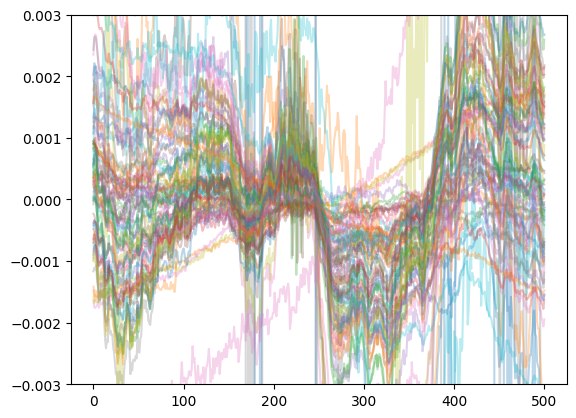

In [76]:
plt.figure()
for i in range(len(interferograms1_90_v2[::2])):
    plt.plot(interferograms1_90_v2[i], alpha=0.3)
# plt.xlim(200, 250)
plt.ylim(-0.003, 0.003)
plt.show()

# 15. Frequency array

In [60]:
len(interferograms1Q_90_v2[i])

501

In [61]:
#### initialize some constants
c=3e8     # speed of light

FTS_frequency_cal = 1.0239  # FTS calibration factor- based on the path length difference not
                            # being exactly, found in raytracing simulations and verified via
                            # the geometry of the FTS layout
        
spike_threshold = 15.  ## S/N of a spike
cut_threshold = 5  ## ratio rms(center)/rms(sides) of interferogram

# This should be the smallest throw we see in all the runs
FTS_stage_step_size = 0.15 * 1e-3  # FTS step size in meters
FTS_stage_throw  = 37.5*2. *1e-3      # total throw extent in meters 

# estimate the resolution and Nyquist frequency    
Nyquist_Freuqency= (c/FTS_stage_step_size/4.)/2. * FTS_frequency_cal
Resolution = c/FTS_stage_throw/4.* FTS_frequency_cal
print("Nyquist frequency: ", Nyquist_Freuqency/1e9, "GHz")
print("FTS resolution: ", Resolution/1e9, "GHz")

# n_samples = len(band_dsT)*2
n_samples = 501
print(f'n_samples:{n_samples}')
# freq = bp.frequency(np.ones(n_samples), c, FTS_stage_step_size, FTS_frequency_cal)

Nyquist frequency:  255.97500000000002 GHz
FTS resolution:  1.0239 GHz
n_samples:501


# 16. Phase angles

In [124]:
namesofdets = obs1_90.dets.vals

In [123]:
namesofdets = list(namesofdets)

TypeError: 'LabelAxis' object is not iterable

In [ ]:
# regenerate freq array
freq_v2 = bp.frequency(np.ones(2 * len(phase_angles_90[0])), c, FTS_stage_step_size, FTS_frequency_cal, prints=True)

In [125]:
namesofdets[88]

'sch_ufm_mv18_1765462613_5_346'

In [62]:
phase_angles_90 = []
phase_angles_90.clear()

for i in indices90:
    if i == 88:
        continue

    demodQ_cleaned = interferograms1Q_90_v2[i]
    demodU_cleaned = interferograms1U_90_v2[i]

    # store the Q and U bands
    bandQ, max_i = bp.get_cleaned_interferogram(demodQ_cleaned, 5, 10, 7, max_ind = 225, polyfit=True, center_interf=True)
    # print(f'max_i {max_i}')
    bandU, max_i = bp.get_cleaned_interferogram(demodU_cleaned, 5, 10, 7, max_ind = 225, polyfit=True, center_interf=True)
    # print(f'max_i {max_i}')
    
    # band = np.sqrt(bandQ**2 + bandU**2)
    angles = 0.5 * np.arctan2(bandU, bandQ) * 180./np.pi
    phase_angles_90.append(angles)
    # plt.plot(freq[mask90]/1e9, angles[mask90]-35, color='C0', alpha=0.8) # -26
    # plt.plot(freq[mask90]/1e9, band[mask90]/np.max(band), label=f'i{i}')

#     # also store (xi, eta, gamma)
#     xi_ = xi_90_v1[i]
#     eta_ = eta_90_v1[i]
#     gamma_ = gamma_90_v1[i]

# # separately also want to store the frequency array which is:
# freq_v2/1e9

In [126]:
detector_data_90 = {}

for i in indices90:
    if i == 88:
        continue
    demodQ_cleaned = interferograms1Q_90_v2[i]
    demodU_cleaned = interferograms1U_90_v2[i]

    bandQ, max_i = bp.get_cleaned_interferogram(demodQ_cleaned, 5, 10, 7, max_ind=225, polyfit=True, center_interf=True)
    bandU, max_i = bp.get_cleaned_interferogram(demodU_cleaned, 5, 10, 7, max_ind=225, polyfit=True, center_interf=True)

    angles = 0.5 * np.arctan2(bandU, bandQ) * 180. / np.pi
    phase_angles_90.append(angles)

    detector_data_90[i] = {
        'bandQ': bandQ,
        'bandU': bandU,
        'xi':    xi_90_v1[i],
        'eta':   eta_90_v1[i],
        'gamma': gamma_90_v1[i],
        'det_name': obs1_90.dets.vals,
        'det_band': obs1_90.det_info.smurf.band,
        'det_channel': obs1_90.det_info.smurf.channel, 
    }

detector_data_90['freq_GHz'] = freq_v2 / 1e9

In [103]:
freq_v2[-1]/1e9

254.84236725663717

In [64]:
indices90

[92, 101, 55, 82]

In [127]:
with open(f'/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv18/detector_data_90_HWPrun1_260623.pkl', 'wb') as f:
    pickle.dump(detector_data_90, f)

In [85]:
# xi90_4dets = obs1_90.focal_plane.xi
# eta90_4dets = obs1_90.focal_plane.eta
# gamma90_4dets = obs1_90.focal_plane.gamma

# print('xi90_4dets = ', xi90_4dets[[92, 101, 55, 82]])
# print('eta90_4dets = ', eta90_4dets[[92, 101, 55, 82]])
# print('gamma90_4dets = ', gamma90_4dets[[92, 101, 55, 82]])

xi90_4dets =  [-0.05248951 -0.04359193 -0.04359193 -0.05248951]
eta90_4dets =  [0.20854187 0.19361494 0.19361494 0.20854187]
gamma90_4dets =  [0. 0. 0. 0.]


In [96]:
# len(xi90_4dets)

156

In [87]:
# xi150_keptdets = obs1_150.focal_plane.xi
# eta150_keptdets = obs1_150.focal_plane.eta
# gamma150_keptdets = obs1_150.focal_plane.gamma

# print('xi150_keptdets = ', xi150_keptdets[indices150])
# print('eta150_keptdets = ', eta150_keptdets[indices150])
# print('gamma150_keptdets = ', gamma150_keptdets[[92, 101, 55, 82]])

xi150_keptdets =  [-0.05248951 -0.05716475 -0.05716475 -0.05248951 -0.04805493 -0.06184954
 -0.04805493 -0.06184954 -0.04359193 -0.04826603 -0.05294932 -0.05294932
 -0.0344395  -0.04359193 -0.04826603 -0.05272965 -0.05741379 -0.05741379]
eta150_keptdets =  [0.20854187 0.20098391 0.20098391 0.20854187 0.20111066 0.1933732
 0.20111066 0.1933732  0.19361494 0.18596327 0.17826217 0.17826217
 0.1937029  0.19361494 0.18596327 0.19350508 0.18584849 0.18584849]
gamma150_keptdets =  [0. 0. 0. 0.]


In [112]:
# len(phase_angles_90[0])

226

Input, fts_stage_step_size 0.00015
Input, fts_frequency_cal 1.0239
N_samples_kept: 452
Resolution: 1132632743.3628318


In [67]:
avg_phases90 = []
stds_90 = []
avg_phases90.clear()
stds_90.clear()

for i in range(len(phase_angles_90[0])): # gather every detectors' phase shift value at frequency x
    phases_at_freq = []
    for j in range(len(phase_angles_90)):
        phase_singledet_single_freq = phase_angles_90[j][i]
        phases_at_freq.append(phase_singledet_single_freq) # from this, get the standard deviation and average value
    # get the average
    mean_phase_at_freq = np.mean(phases_at_freq)
    std_at_freq = np.std(phases_at_freq)
    avg_phases90.append(mean_phase_at_freq)
    stds_90.append(std_at_freq)
    phases_at_freq.clear()

In [95]:
phase_angles_150 = []
phase_angles_150.clear()

for i in indices150:
    if i == 51:
        continue
    demodQ_cleaned = interferograms1Q_150_v2[i]
    demodU_cleaned = interferograms1U_150_v2[i]

    # # check by eye what the max_ind arg should be to center window over interferogram
    # bandQ, _ = bp.get_cleaned_interferogram(demodQ_cleaned, 5, 10, 7, plot=True, polyfit=True, center_interf= True)
    # print(_)
    # bandU, _ = bp.get_cleaned_interferogram(demodU_cleaned, 5, 10, 7, plot=True, polyfit=True, center_interf= True)
    # print(_)

    # chose max_ind = 225 just for consistency
    bandQ, _ = bp.get_cleaned_interferogram(demodQ_cleaned, 5, 10, 7, max_ind = 225, polyfit=True, center_interf= True)
    bandU, _ = bp.get_cleaned_interferogram(demodU_cleaned, 5, 10, 7, max_ind = 225, polyfit=True, center_interf= True)
    
    # band = np.sqrt(bandQ**2 + bandU**2)
    angles = 0.5 * np.arctan2(bandU, bandQ) * 180./np.pi
    phase_angles_150.append(angles)
    # plt.plot(freq[mask90]/1e9, angles[mask90]-35, color='C0', alpha=0.8) # -26
    # plt.plot(freq[mask90]/1e9, band[mask90]/np.max(band), label=f'i{i}')

#     # also store the xi, eta, and gamma values of each
# gamma_90_v2 = obs1_90.focal_plane.gamma.copy()
#     xi = xi_150_v

In [128]:
detector_data_150 = {}
for i in indices150:
    if i == 51:
        continue
    demodQ_cleaned = interferograms1Q_150_v2[i]
    demodU_cleaned = interferograms1U_150_v2[i]
    bandQ, _ = bp.get_cleaned_interferogram(demodQ_cleaned, 5, 10, 7, max_ind=225, polyfit=True, center_interf=True)
    bandU, _ = bp.get_cleaned_interferogram(demodU_cleaned, 5, 10, 7, max_ind=225, polyfit=True, center_interf=True)
    angles = 0.5 * np.arctan2(bandU, bandQ) * 180. / np.pi
    phase_angles_150.append(angles)
    detector_data_150[i] = {
        'bandQ': bandQ,
        'bandU': bandU,
        'xi':    xi_150_v1[i],
        'eta':   eta_150_v1[i],
        'gamma': gamma_150_v1[i],
        'det_name':    obs1_150.dets.vals,
        'det_band':    obs1_150.det_info.smurf.band,
        'det_channel': obs1_150.det_info.smurf.channel,
    }
detector_data_150['freq_GHz'] = freq_v2 / 1e9

In [130]:
# Save the detector bands and their positions and such
with open(f'/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv18/detector_data_150_HWPrun1_260623.pkl', 'wb') as f:
    pickle.dump(detector_data_150, f)

In [131]:
print(len(interferograms1_150_v2[0]))
print(len(xi_150_v1))
print(obs1_150.dets.count)

501
216
216


In [89]:
avg_phases150 = []
stds_150 = []
avg_phases150.clear()
stds_150.clear()

for i in range(len(phase_angles_150[0])): # gather every detectors' phase shift value at frequency x
    phases_at_freq = []
    for j in range(len(phase_angles_150)):
        phase_singledet_single_freq = phase_angles_150[j][i]
        phases_at_freq.append(phase_singledet_single_freq) # from this, get the standard deviation and average value
    # get the average
    mean_phase_at_freq = np.mean(phases_at_freq)
    std_at_freq = np.std(phases_at_freq)
    avg_phases150.append(mean_phase_at_freq)
    stds_150.append(std_at_freq)
    phases_at_freq.clear()

In [103]:
phase_singledet_single_freq

29.889802311592256

In [90]:
avg_phases90

[31.13453520874746,
 30.349154453304095,
 30.617189720057006,
 30.322967234948628,
 30.23377776130185,
 33.20354653100227,
 32.9056236924892,
 27.076262332278887,
 30.473777067992156,
 28.300238516641965,
 28.000982809358987,
 28.86457057714997,
 23.74827436254913,
 30.8306690584313,
 28.670699295386445,
 17.45071533713275,
 13.276998088502497,
 19.91109855655248,
 23.430410738579305,
 19.016373399910265,
 18.79910266580422,
 25.78617634406116,
 18.014431901973207,
 19.349401875637714,
 25.09335787681556,
 31.69304944022091,
 27.47758904362204,
 29.76668502369883,
 19.33916993739819,
 21.03839219201182,
 19.91265319147821,
 22.067752452622376,
 17.685635761237354,
 19.804492697732094,
 20.329625591361022,
 22.873974592443467,
 25.113296319080735,
 19.088491360544594,
 27.322007545478506,
 23.59042210502107,
 27.676010755471907,
 35.804180976835376,
 28.782218851318213,
 22.33894357789008,
 16.78023199407302,
 19.25209013153516,
 27.63688044921781,
 22.743914810991487,
 19.8039573064332

## Plot

In [91]:
# set the in-band frequency regions
freq_ends90 = [70, 120]
freq_ends150 = [125, 170]

In [92]:
# create masks for the in-band regions
mask90_v2 = np.where(((freq_v2/1e9) >= freq_ends90[0]) & ((freq_v2/1e9) <= freq_ends90[1]))
mask150_v2 = np.where(((freq_v2/1e9) >= freq_ends150[0]) & ((freq_v2/1e9) <= freq_ends150[1]))

In [93]:
c

300000000.0

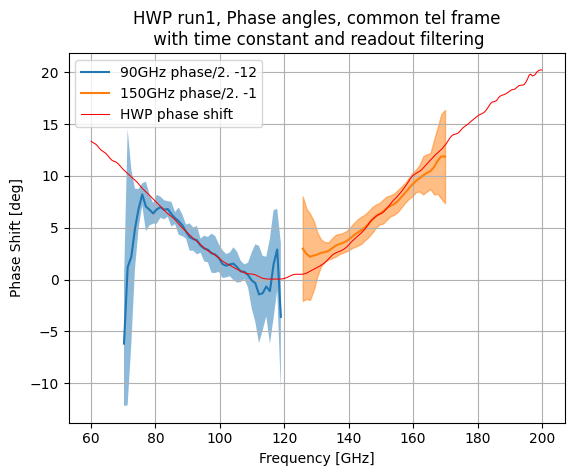

In [156]:
plt.figure()

# # when not dividing by 2
# shift90 = -26
# shift150 = -8

shift90 =-12
shift150 = -1

# this plotting no longer works
plt.fill_between(freq_v2[mask90_v2]/1e9, np.array(avg_phases90)[mask90_v2] / 2.+ shift90 - np.array(stds_90)[mask90_v2], np.array(avg_phases90)[mask90_v2] / 2. + shift90 + np.array(stds_90)[mask90_v2],alpha=0.5)
plt.plot(freq_v2[mask90_v2]/1e9, np.array(avg_phases90)[mask90_v2]/2. + shift90 , alpha=1, color='C0', label=f'90GHz phase/2. {shift90}')

plt.fill_between(freq_v2[mask150_v2]/1e9, np.array(avg_phases150)[mask150_v2]/2. + shift150 - np.array(stds_150)[mask150_v2], np.array(avg_phases150)[mask150_v2]/2. +shift150 + np.array(stds_150)[mask150_v2],alpha=0.5, color='C1')
plt.plot(freq_v2[mask150_v2]/1e9, np.array(avg_phases150)[mask150_v2]/2. + shift150, alpha=1, color='C1', label=f'150GHz phase/2. {shift150}')

plt.plot(mf1_ahwp['frequency (GHz)'], mf1_ahwp['phase shift (deg)'], color='r', label='HWP phase shift', lw=0.75)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Phase Shift [deg]')
plt.title('HWP run1, Phase angles, common tel frame\n with time constant and readout filtering')
plt.grid()
plt.legend()
plt.show()

# Save 
1. bands, freq, (band, channel), (det_name), xi, eta, gamma, theta_cad -- saved earlier in notebook
2. Average phases 90
3. average phases 150
4. stds90
5. stds150

In [133]:
phases_dict = {'freq': freq_v2/1e9,
            'avg_phases90': np.array(avg_phases90),
            'avg_phases150': np.array(avg_phases150),
            'stds90': np.array(stds_90),
            'stds150': np.array(stds_150),
            'angle_shift90': shift90,
            'angle_shift150': shift150}

In [136]:
with open(f'/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv18/phases_avg_run1_260527.pkl', 'wb') as f:
    pickle.dump(phases_dict, f)

# SCRATCH
Everything below is scratch work and should not be run.

# ---- do not run cells below ---

# Distance from center of array

Slack message with positions of wafer centers:
https://simonsobs.slack.com/archives/CKQGPU9JB/p1754316979855549?thread_ts=1754313895.146119&cid=CKQGPU9JB

In [147]:
# obs1_90.focal_plane.xi

In [59]:
def get_dist(x1, y1, x2, y2):
    return np.sqrt((x2-x1)**2 + (y2-y1)**2)

In [60]:
# Center of array
x_wc, y_wc = 0.0, 12.634 # from a slack message 

# Calculate distances of each det to the center
distances90 = []
distances90.clear()

for i in indices90:
    x2, y2 = np.degrees(obs1_90.focal_plane.xi[i]), np.degrees(obs1_90.focal_plane.eta[i])
    dist = get_dist(x_wc, y_wc, x2, y2)
    distances90.append(dist)

In [61]:
print(distances90)

[3.084547780773681, 2.9345989534388206, 2.9345989534388206, 3.084547780773681]


In [62]:
# Calculate distances of each det to the center
distances150 = []
distances150.clear()

for i in indices150:
    x2, y2 = np.degrees(obs1_150.focal_plane.xi[i]), np.degrees(obs1_150.focal_plane.eta[i])
    dist = get_dist(x_wc, y_wc, x2, y2)
    distances150.append(dist)

In [96]:
len(distances150)

18

# Plot

## polarization angles (HWP optical axis)

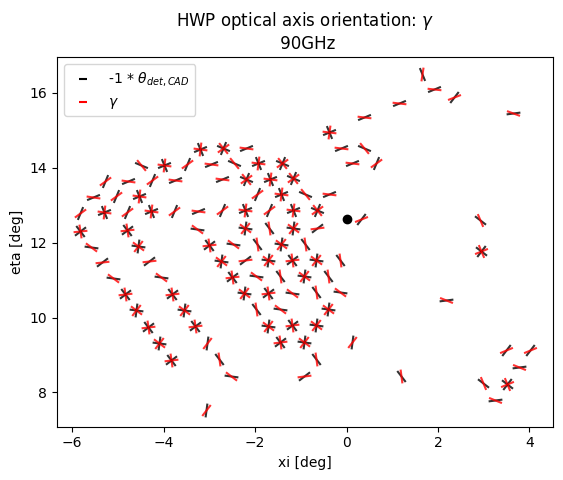

In [114]:
plt.figure()
# plt.scatter(xi_90_v1, eta_90_v1)
# plt.scatter(x_90_v1, y_90_v1)

# to resolve discrepancy between gamma and theta, need to add 30 deg to gamma.
# gamma_fixed = gamma + 30
for i, (x, y, angle, gamma) in enumerate(zip(np.degrees(xi_90_v1), np.degrees(eta_90_v1), -1*np.degrees(pang_90_v1_wrap), np.degrees(gamma_90_v1_wrap))):
    marker1 = MarkerStyle('|').rotated(deg=angle)
    marker2 = MarkerStyle('|').rotated(deg=gamma)
    plt.scatter(x, y, marker=marker1, color='k', alpha=0.8, s=100,
                label='90GHz dets, hwp run1, v1' if i == -1 else None)
    plt.scatter(x, y, marker=marker2, color='r', alpha=0.8, s=100,
                label='90GHz dets, hwp run1, v1' if i == -1 else None)

# Plot center of wafer
plt.scatter([0.0], [12.634], color='k')

# # 150GHz
# for i, (x, y, angle, gamma) in enumerate(zip(np.degrees(xi_150_v1), np.degrees(eta_150_v1), pang_150_v1, np.degrees(gamma_150_v1))):
#     marker1 = MarkerStyle('|').rotated(deg=angle)
#     marker2 = MarkerStyle('|').rotated(deg=gamma)
#     # plt.scatter(x, y, marker=marker1, color='k', alpha=0.8, s=100,
#     #             label='150GHz dets, hwp run1, v1' if i == -1 else None)
#     plt.scatter(x, y, marker=marker2, color='b', alpha=0.8, s=100,
#                 label='150GHz dets, hwp run1, v1' if i == -1 else None)
    
marker1 = MarkerStyle('|').rotated(deg=90)
marker2 = MarkerStyle('|').rotated(deg=90)
plt.scatter([],[], marker=marker1, color='k', label=r'-1 * $\theta_{det,CAD}$')
plt.scatter([],[], marker=marker2, color='r', label=r'$\gamma$')

# plt.xlim(-2, 0)
# plt.ylim(10, 12)
# plt.title(r'HWP optical axis orientation: $\theta_{det, CAD}$' + '\n 90GHz')
plt.title(r'HWP optical axis orientation: $\gamma$' + '\n 90GHz')

# plt.title(r'HWP optical axis orientation: Comparing $\theta_{det, CAD}$ and $\gamma$' + '\n 90GHz')
plt.xlabel('xi [deg]')
plt.ylabel('eta [deg]')
plt.legend()
plt.show()

okay! gamma seems to be -30 degrees off from nominal, so Erin  is going to investigate that more before asking dm-calibration-pointing

In [123]:
pang_150_v1.shape

AttributeError: 'builtin_function_or_method' object has no attribute 'shape'

In [121]:
plt.figure()
# plt.scatter(xi_90_v1, eta_90_v1)
# plt.scatter(x_90_v1, y_90_v1)

for i, (x, y, angle, gamma) in enumerate(zip(np.degrees(xi_150_v1), np.degrees(eta_150_v1), pang_150_v1, np.degrees(gamma_150_v1))):
    marker1 = MarkerStyle('|').rotated(deg=angle)
    marker2 = MarkerStyle('|').rotated(deg=gamma)
    plt.scatter(x, y, marker=marker1, color='k', alpha=0.8, s=100,
                label='150GHz dets, hwp run1, v1' if i == -1 else None)
    plt.scatter(x, y, marker=marker2, color='r', alpha=0.8, s=100,
                label='150GHz dets, hwp run1, v1' if i == -1 else None)
marker1 = MarkerStyle('|').rotated(deg=90)
marker2 = MarkerStyle('|').rotated(deg=90)
plt.scatter([],[], marker=marker1, color='k', label=r'$\theta_{det,CAD}$')
plt.scatter([],[], marker=marker2, color='r', label=r'$\gamma$')

# plt.xlim(-2, 0)
# plt.ylim(10, 12)
plt.title(r'HWP optical axis orientation: Comparing $\theta_{det, CAD}$ and $\gamma$' + '\n 150GHz')
plt.xlabel('xi [deg]')
plt.ylabel('eta [deg]')
plt.legend()
plt.show()

TypeError: 'builtin_function_or_method' object is not iterable

<Figure size 640x480 with 0 Axes>

Next: I guess the coordinate transformations I'd  like to try are those that Max S talked about:
1) telescope reference frame (but is there a way to update either gammas or detectors angles somehow? Look into that
2) radial frame, with respect to the focal plane, I just want to see what's up
3) I think the gamma could come from SWG calibration, but I need to check if that's the case

In [114]:
# gammas at 90GHz vs 150GHz
diff_90s =  pang_90_v1 - np.degrees(gamma_90_v1)

In [116]:
#  wrap
diff_90s_wrap = (np.radians(diff_90s)) % (2 * np.pi) - np.pi

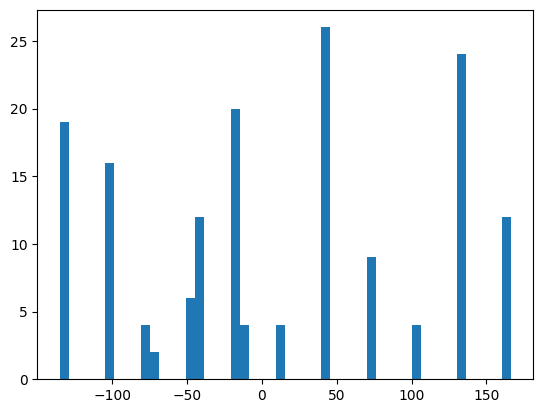

In [119]:
plt.figure()
# plt.hist(diff_90s, bins=50)
plt.hist(np.degrees(diff_90s_wrap),bins=50)
plt.show()

## Common telescope frame
1. So the polarization angles, $\theta_{det, CAD}$ do not change due to coordinate frame changes.
2. $\gamma$ does change as a result of the coordinate frame changes

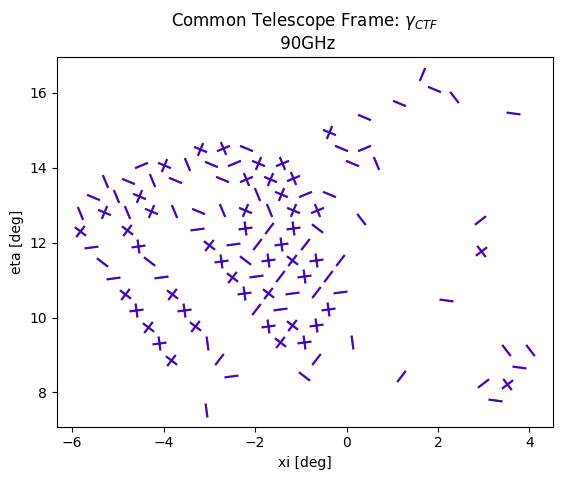

In [64]:
plt.figure()
# plt.scatter(xi_90_v1, eta_90_v1)
# plt.scatter(x_90_v1, y_90_v1)

for i, (x, y, anglev1, anglev2) in enumerate(zip(np.degrees(xi_90_v2), np.degrees(eta_90_v2), pang_90_v1, pang_90_v2)):
    marker1 = MarkerStyle('|').rotated(deg=anglev1)
    marker2 = MarkerStyle('|').rotated(deg=anglev2)
    plt.scatter(x, y, marker=marker1, color='r', alpha=0.8, s=100,
                label='90GHz dets, hwp run1, v1' if i == -1 else None)
    plt.scatter(x, y, marker=marker2, color='b', alpha=0.8, s=100,
                label='90GHz dets, hwp run1, v1' if i == -1 else None)
marker1 = MarkerStyle('|').rotated(deg=90)
marker2 = MarkerStyle('|').rotated(deg=90)
plt.scatter([],[], marker=marker1, color='r', label=r'$\gamma_{HwpOptAx}$')
plt.scatter([],[], marker=marker2, color='b', label=r'$\gamma_{CTF}$')

# plt.xlim(-2, 0)
# plt.ylim(10, 12)
# plt.title(r'HWP optical axis orientation: $\theta_{det, CAD}$' + '\n 90GHz')
# plt.title(r'HWP optical axis orientation: $\gamma$' + '\n 90GHz')

# plt.title(r'Common Telescope Frame: Comparing $\gamma_{HwpOptAx}$ and $\gamma_{CTF}$' + '\n 90GHz')
plt.title(r'Common Telescope Frame: $\gamma_{CTF}$' + '\n 90GHz')

plt.xlabel('xi [deg]')
plt.ylabel('eta [deg]')
# plt.legend()
plt.show()

I'm  wondering about the MarkerStyle rotation, should it be with respect to xi instead of eta? Right now it is with respect to eta.

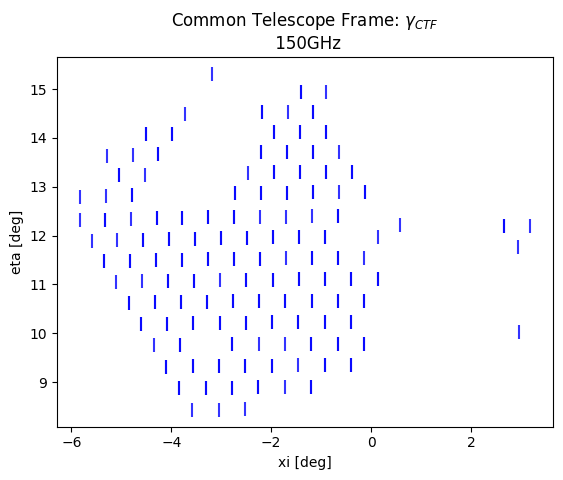

In [102]:
plt.figure()
# plt.scatter(xi_90_v1, eta_90_v1)
# plt.scatter(x_90_v1, y_90_v1)

for i, (x, y, gammav1, gammav2) in enumerate(zip(np.degrees(xi_150_v2), np.degrees(eta_150_v2), np.degrees(gamma_150_v1), np.degrees(gamma_150_v2))):
    marker1 = MarkerStyle('|').rotated(deg=gammav1)
    marker2 = MarkerStyle('|').rotated(deg=gammav2)
    # plt.scatter(x, y, marker=marker1, color='r', alpha=0.8, s=100,
    #             label='90GHz dets, hwp run1, v1' if i == -1 else None)
    plt.scatter(x, y, marker=marker2, color='b', alpha=0.8, s=100,
                label='90GHz dets, hwp run1, v1' if i == -1 else None)
marker1 = MarkerStyle('|').rotated(deg=90)
marker2 = MarkerStyle('|').rotated(deg=90)
plt.scatter([],[], marker=marker1, color='r', label=r'$\gamma_{HwpOptAx}$')
plt.scatter([],[], marker=marker2, color='b', label=r'$\gamma_{CTF}$')

# plt.xlim(-2, 0)
# plt.ylim(10, 12)
# plt.title(r'HWP optical axis orientation: $\theta_{det, CAD}$' + '\n 90GHz')
# plt.title(r'HWP optical axis orientation: $\gamma$' + '\n 90GHz')

# plt.title(r'Common Telescope Frame: Comparing $\gamma_{HwpOptAx}$ and $\gamma_{CTF}$' + '\n 150GHz')
plt.title(r'Common Telescope Frame: $\gamma_{CTF}$' + '\n 150GHz')

plt.xlabel('xi [deg]')
plt.ylabel('eta [deg]')
# plt.legend()
plt.show()

## demodQ and U compare

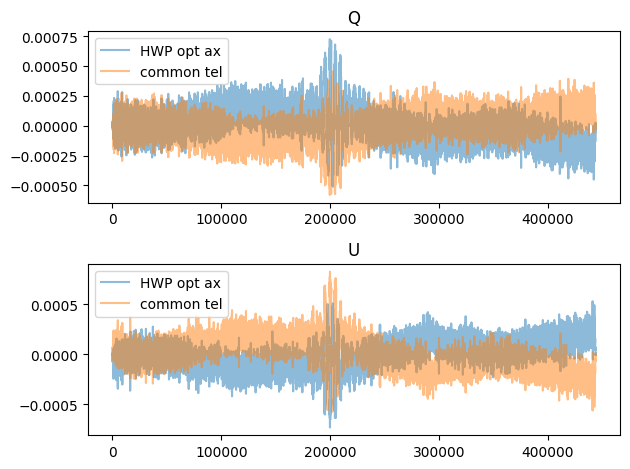

In [117]:
fig, ax = plt.subplots(2, 1)

i = 4
demodQ_v1 = demodQs_90[i] 
demodQ_v2 = demodQs_90_v2[i]

demodU_v1 = demodUs_90[i] 
demodU_v2 = demodUs_90_v2[i]

ax[0].set_title('Q')
ax[0].plot(demodQ_v1, alpha=0.5, label='HWP opt ax')
ax[0].plot(demodQ_v2, alpha=0.5, label='common tel')

ax[1].set_title('U')
ax[1].plot(demodU_v1, alpha=0.5, label='HWP opt ax')
ax[1].plot(demodU_v2, alpha=0.5, label='common tel')

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

I don't find this particularly illuminating. It would be good have a percentage of Q and a percentage of U value. 

But I wonder if we have to get the bands first, in which case, I can now only get to the bands of the common telescope reference frame detectors. Or maybe there is a way (surely there is) to clean up the fts_routines.py or whatever to take in the raw arrays of demodQs_90/150 and demodUs_90/150

## Bands, phase angles

In [78]:
# set the in-band frequency regions
freq_ends90 = [70, 120]
freq_ends150 = [125, 170]

In [79]:
# create masks for the in-band regions
mask90 = np.where(((freq/1e9) >= freq_ends90[0]) & ((freq/1e9) <= freq_ends90[1]))
mask150 = np.where(((freq/1e9) >= freq_ends150[0]) & ((freq/1e9) <= freq_ends150[1]))

In [74]:
len(indices90)
len(distances90)
distances90[1] * 0.5

NameError: name 'distances90' is not defined

In [178]:
distances90

[4.371566667705723,
 3.084547780773681,
 2.9345989534388206,
 2.9345989534388206,
 3.084547780773681]

In [107]:
max_d, min_d = np.max(distances90), np.min(distances90)
print(max_d, min_d)

# # t --> 0 (purple) when detectors are farther away
# for dist in distances90:
#     t = (max_d - dist) / (max_d - min_d)
#     print(f'dist ={dist}, t {t}')

# t --> 1 (yellow) when detectors are farther away
for dist in distances90:
    t = (dist - min_d) / (max_d - min_d)
    print(f'dist ={dist}, t {t}')

3.084547780773681 2.9345989534388206
dist =3.084547780773681, t 1.0
dist =2.9345989534388206, t 0.0
dist =2.9345989534388206, t 0.0
dist =3.084547780773681, t 1.0


In [1]:
indices90[0]

NameError: name 'indices90' is not defined

t=1
t=1
t=0


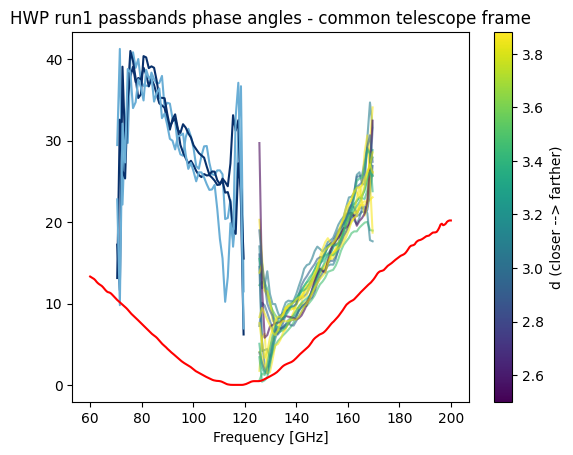

In [114]:
plt.figure()

for i, det_idx in enumerate(indices90):
    if det_idx == 88:
        continue
        
    # lighten depending on  distance from center
    max_d, min_d = np.max(distances90), np.min(distances90)
    t = ((max_d - distances90[i]) / (max_d - min_d))
    
    demodQ_cleaned = interferograms1Q_90_v2[det_idx]
    demodU_cleaned = interferograms1U_90_v2[det_idx]
    bandQ = bp.get_cleaned_interferogram(demodQ_cleaned, 5, 10, 7, polyfit=True)
    bandU = bp.get_cleaned_interferogram(demodU_cleaned, 5, 10, 7, polyfit=True)
    band = np.sqrt(bandQ**2 + bandU**2)
    angles = 0.5 * np.arctan2(bandU, bandQ) * 180./np.pi

    color = plt.cm.Blues(0.5 + 0.5*t)

    # color = plt.cm.YlGnBu(0.2 + 0.8 * t)   # yellow (far) → dark blue (close)
    # color = plt.cm.winter(t**2)

    # far_color  = np.array([0.7, 0.85, 1.0])   # light blue for far detectors
    # near_color = np.array([0.05, 0.15, 0.5])  # dark navy for close detectors
    # color = (1 - t) * far_color + t * near_color

    plt.plot(freq[mask90]/1e9, angles[mask90], alpha=1, color=color, label=f'{np.round(distances90[i], 2)}') # -26
    # plt.plot(freq[mask90]/1e9, band[mask90]/np.max(band), label=f'i{i}')

# lighten depending on  distance from center
max_d, min_d = np.max(distances150), np.min(distances150)
    
for i, det_idx in enumerate(indices150):
    if det_idx == 51:
        print(f'ommitted i, det_idx {i}, {det_idx}')
        continue

    # lighten depending on distance from center. Darkest near the center.
    t = ((distances150[i] - min_d) / (max_d - min_d))
    
    demodQ_cleaned = interferograms1Q_150_v2[det_idx]
    demodU_cleaned = interferograms1U_150_v2[det_idx]
    bandQ = bp.get_cleaned_interferogram(demodQ_cleaned, 5, 10, 7, polyfit=True)
    bandU = bp.get_cleaned_interferogram(demodU_cleaned, 5, 10, 7, polyfit=True)
    band = np.sqrt(bandQ**2 + bandU**2)
    angles = 0.5 * np.arctan2(bandU, bandQ) * 180./np.pi

    # color = plt.cm.viridis(0.3 + 0.7*t)
    if t == 0:
        print('t=0')
        t = 0.01
    if t == 1:
        print('t=1')
        t = 0.99
    color = plt.cm.viridis(t)
    # print(t)
    
    plt.plot(freq[mask150]/1e9, angles[mask150], alpha=0.6, color=color, label=f'{np.round(distances150[i], 2)}') # -9
    # plt.plot(freq[mask150]/1e9, band[mask150]/np.max(band), label=f'i{i}')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min_d, vmax=max_d))
sm.set_array([])
plt.colorbar(sm, ax = plt.gca(), label='d (closer --> farther)')

# plt.legend()
plt.plot(mf1_ahwp['frequency (GHz)'], mf1_ahwp['phase shift (deg)'], color='r', label='HWP phase shift')
plt.title('HWP run1 passbands phase angles - common telescope frame')
plt.xlabel('Frequency [GHz]')
plt.show()

<b>Next:</b> could normalize these all the same such that the colorbar could apply to all the dets (90s and 150s)

## Histogram of gammas

In [108]:
# need to wrap the gammas first
gamma_90_v1_wrap = (gamma_90_v1 + np.pi) % (2 * np.pi) - np.pi
gamma_150_v1_wrap = (gamma_150_v1 + np.pi) % (2 * np.pi) - np.pi

In [109]:
# wrap the angles_det, CAD
pang_90_v1_wrap = (np.radians(pang_90_v1)) % (2 * np.pi) - np.pi

In [110]:
counts_pang_90_v1_wrap, bin_edges_pang_90_v1_wrap = np.histogram(np.degrees(pang_90_v1_wrap), bins=50)

In [111]:
for i in range(50):
    print(np.average(counts_pang_90_v1_wrap[i]))

16.0
0.0
6.0
0.0
0.0
0.0
0.0
24.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
9.0
0.0
0.0
0.0
0.0
0.0
24.0
0.0
12.0
0.0
0.0
0.0
0.0
19.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
18.0
0.0
0.0
0.0
0.0
0.0
4.0
0.0
26.0
0.0
0.0
0.0
0.0
4.0


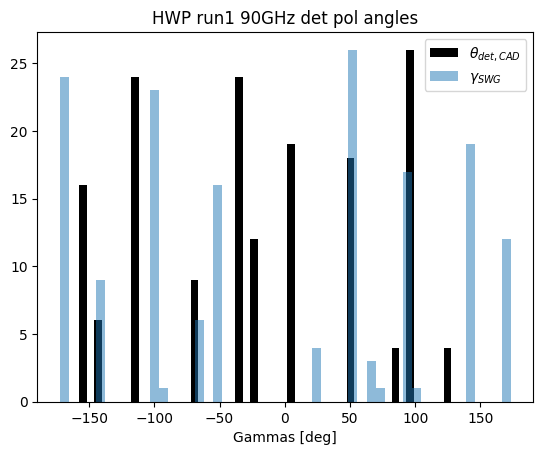

In [105]:
# plot gammas
plt.figure()
# plt.hist((np.degrees(gamma_90_v1) / 2.) - 90., bins=50, alpha=0.5) # unwrapped, default
# plt.hist((np.degrees(gamma_150_v1) / 2.) - 90., bins=50, alpha=0.5) # unwrapped, default
plt.hist(np.degrees(pang_90_v1_wrap), bins=50, alpha=1, color='k', label=r'$\theta_{det, CAD}$')
plt.hist(np.degrees(gamma_90_v1_wrap), bins=50, alpha=0.5, color='C0', label=r'$\gamma_{SWG}$')
# plt.hist(np.degrees(gamma_150_v1_wrap), bins=50, alpha=0.5)
plt.xlabel('Gammas [deg]')
# plt.title('HWP run1, 90/150GHz, Detector pol angles \n gammas from SWG')
plt.title("HWP run1 90GHz det pol angles")
plt.legend()
plt.show()

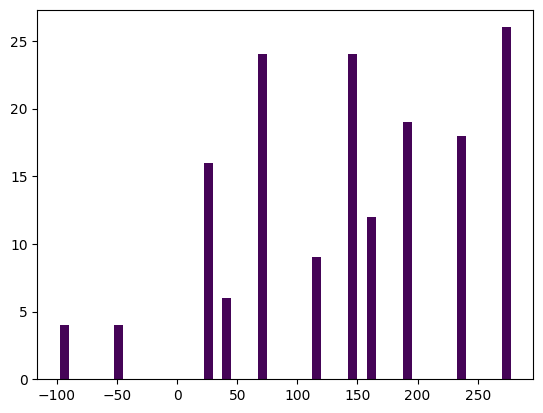

In [100]:
plt.figure()
color = plt.cm.viridis(0.01)

plt.hist(pang_90_v1, bins=50, color = color)
plt.show()